**INSTALAÇÕES E IMPORTS**

In [1]:
!pip install nltk sentence-transformers wordcloud

import pandas as pd
import numpy as np
from tqdm import tqdm
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.stem import PorterStemmer


from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**CARREGANDO A BASE DE DADOS**

In [3]:
df = pd.read_csv("/content/complaints_processed.csv")

In [4]:
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


**PRÉ-PROCESSAMENTO DE TEXTO**

In [5]:
stopwords_en = set(stopwords.words('english'))
stemmer = PorterStemmer()

def limpar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r'http\S+|www.\S+', '', texto)
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def remover_stopwords_e_stem(texto):
    tokens = texto.split()
    tokens_filtrados = []
    for t in tokens:
        if t not in stopwords_en and len(t) > 2:
            t_stem = stemmer.stem(t)
            tokens_filtrados.append(t_stem)
    return " ".join(tokens_filtrados)

df['texto_limpo'] = df['narrative'].apply(limpar_texto)
df['texto_processado'] = df['texto_limpo'].apply(remover_stopwords_e_stem)

df[['narrative', 'texto_processado']].head()


,narrative,texto_processado
0,purchase order day shipping amount receive pro...,purchas order day ship amount receiv product w...
1,forwarded message date tue subject please inve...,forward messag date tue subject pleas investig...
2,forwarded message cc sent friday pdt subject f...,forward messag sent friday pdt subject final l...
3,payment history missing credit report speciali...,payment histori miss credit report special loa...
4,payment history missing credit report made mis...,payment histori miss credit report made mistak...


**CRIAÇÃO DA VARIÁVEL ALVO**

In [6]:
def regra_sentimento(texto):
    if pd.isna(texto):
        return 'Negative'
    t = texto.lower()
    negative_words = [
        'complaint', 'problem', 'issue', 'error', 'wrong charge',
        'overcharge', 'unsatisfied', 'bad', 'terrible', 'refund',
        'delay', 'late', 'fraud'
    ]
    positive_words = [
        'thank you', 'thanks', 'resolved', 'solution',
        'great', 'good', 'satisfied', 'happy'
    ]

    if any(p in t for p in positive_words):
        return 'Positive'
    if any(p in t for p in negative_words):
        return 'Negative'
    return 'Negative'

df['sentiment'] = df['narrative'].apply(regra_sentimento)
df['sentiment'].value_counts()


,count
sentiment,
Negative,135706
Positive,26715


**EMBEDDINGS COM SENTENCE-TRANSFORMERS**

In [7]:
modelo_embeddings = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

sentencas = df['texto_processado'].fillna("").tolist()

batch_size = 512

embeddings_list = []

for i in tqdm(range(0, len(sentencas), batch_size)):
    batch = sentencas[i:i+batch_size]
    batch_embeddings = modelo_embeddings.encode(batch)
    embeddings_list.append(batch_embeddings)

X_embeddings = np.vstack(embeddings_list)

X_embeddings.shape


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

100%|██████████| 318/318 [04:19<00:00,  1.23it/s]


(162421, 384)

**PREPARAÇÃO DOS DADOS**

In [8]:
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])  # 0/1

X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)


**MODELO DE DEEP LEARNING**

In [9]:
input_dim = X_train.shape[1]

modelo = models.Sequential()
modelo.add(layers.Input(shape=(input_dim,)))
modelo.add(layers.Dense(128, activation='relu'))
modelo.add(layers.Dropout(0.3))
modelo.add(layers.Dense(64, activation='relu'))
modelo.add(layers.Dropout(0.3))
modelo.add(layers.Dense(1, activation='sigmoid'))

modelo.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

modelo.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,601 (225.00 KB)

 Trainable params: 57,601 (225.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
hist = modelo.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8638 - loss: 0.3242 - val_accuracy: 0.8697 - val_loss: 0.3016
Epoch 2/10
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8793 - loss: 0.2889 - val_accuracy: 0.8745 - val_loss: 0.2884
Epoch 3/10
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8823 - loss: 0.2789 - val_accuracy: 0.8813 - val_loss: 0.2763
Epoch 4/10
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8849 - loss: 0.2725 - val_accuracy: 0.8841 - val_loss: 0.2703
Epoch 5/10
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8882 - loss: 0.2648 - val_accuracy: 0.8838 - val_loss: 0.2685
Epoch 6/10
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8896 - loss: 0.2605 - val_accuracy: 0.8833 - val_loss: 0.2698
Epoch 7/10
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8904 - loss: 0.2555 - val_accuracy: 0.8868 - val_loss: 0.2651
Epoch 8/10
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8931 - loss: 0.

**AVALIAÇÃO**

In [11]:
y_pred_prob = modelo.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
cm


1016/1016 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

    Negative       0.89      0.99      0.94     27142
    Positive       0.87      0.39      0.54      5343

    accuracy                           0.89     32485
   macro avg       0.88      0.69      0.74     32485
weighted avg       0.89      0.89      0.87     32485



array([[26835,   307],
       [ 3278,  2065]])

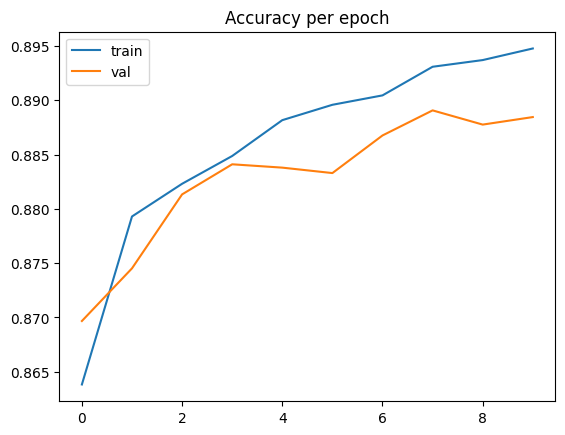

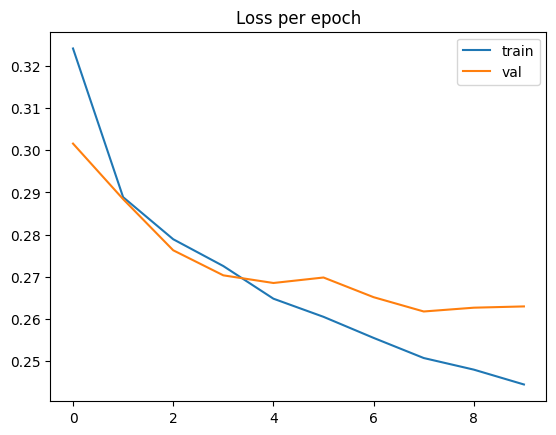

In [12]:
plt.plot(hist.history['accuracy'], label='train')
plt.plot(hist.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy per epoch')
plt.show()

plt.plot(hist.history['loss'], label='train')
plt.plot(hist.history['val_loss'], label='val')
plt.legend()
plt.title('Loss per epoch')
plt.show()


**ANÁLISE DAS DORES DOS CLIENTES**

Filtrando avaliações negativas

In [13]:
df_neg = df[df['sentiment'] == 'Negative'].copy()
df_neg[['narrative', 'product']].head()


,narrative,product
0,purchase order day shipping amount receive pro...,credit_card
1,forwarded message date tue subject please inve...,credit_card
2,forwarded message cc sent friday pdt subject f...,retail_banking
3,payment history missing credit report speciali...,credit_reporting
4,payment history missing credit report made mis...,credit_reporting


Nuvem de palavras

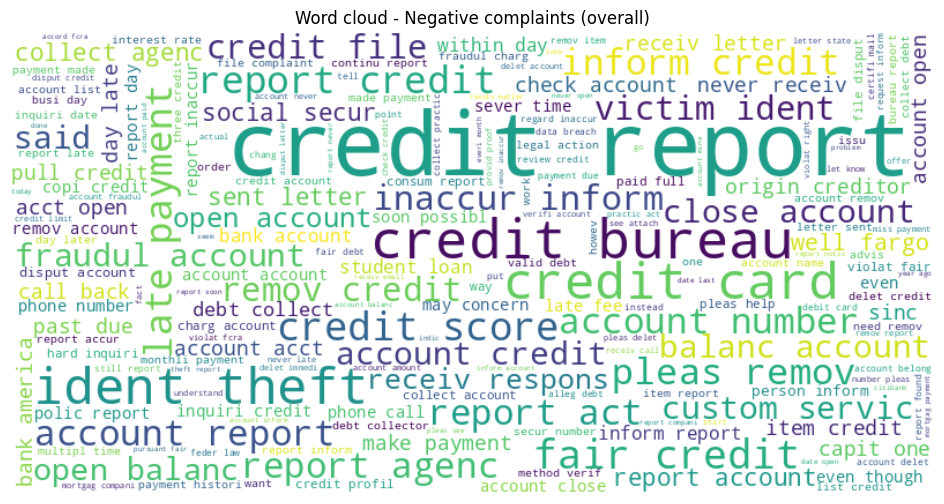

In [14]:
texto_negativo = " ".join(df_neg['texto_processado'].dropna().tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_negativo)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word cloud - Negative complaints (overall)')
plt.show()


Frequência por produto

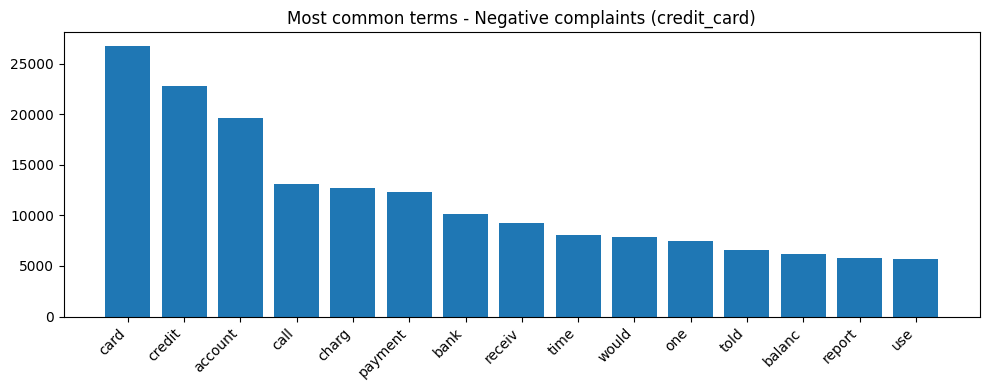

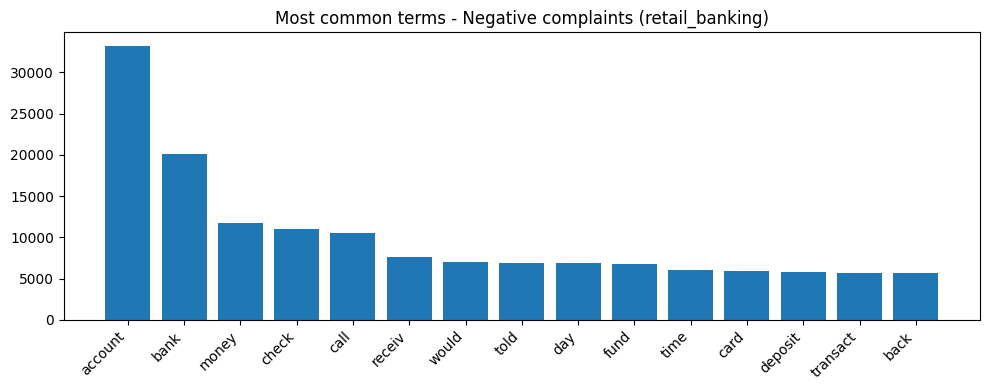

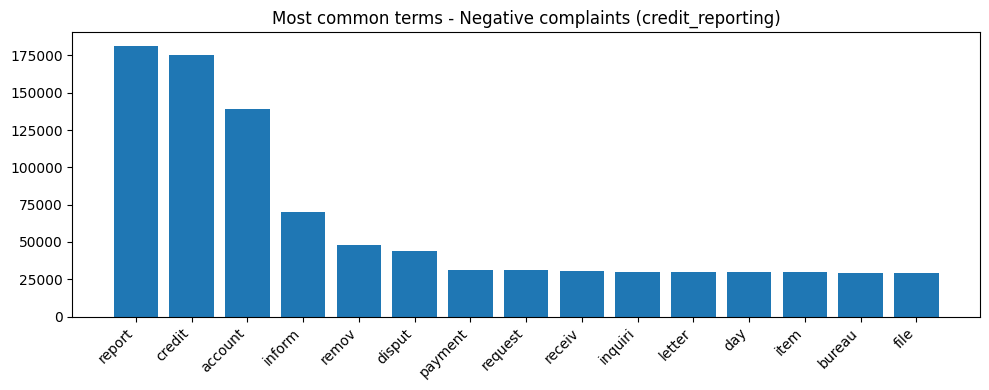

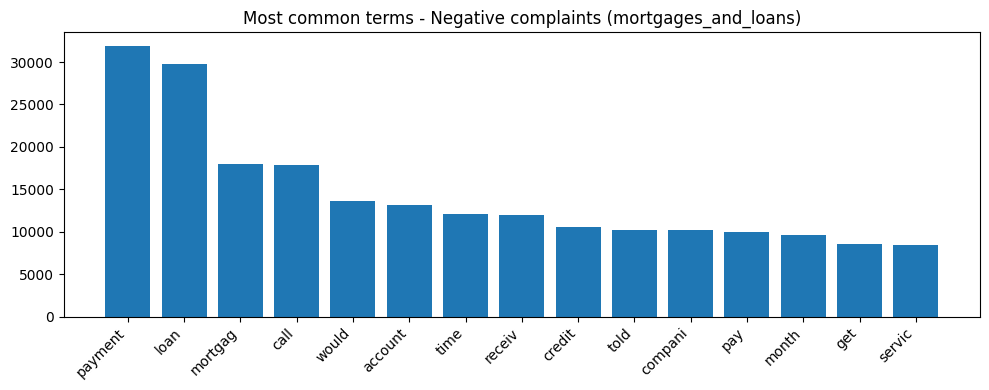

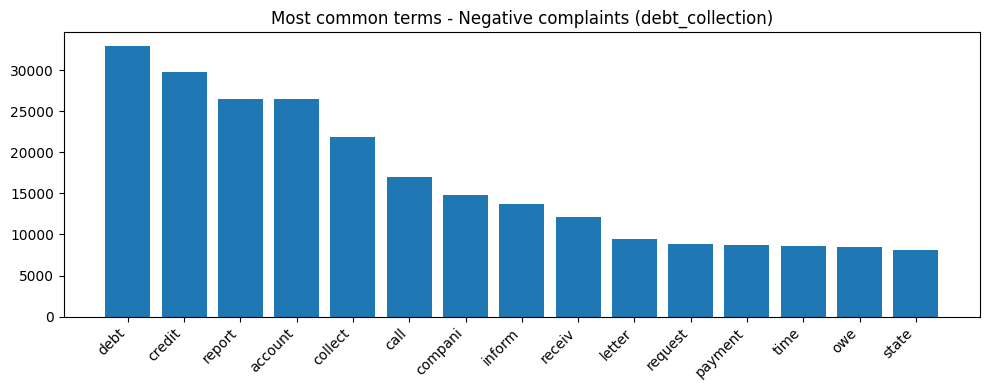

In [15]:
def top_words_by_category(df_cat, n=20):
    texto_cat = " ".join(df_cat['texto_processado'].dropna().tolist())
    tokens = texto_cat.split()
    contagem = Counter(tokens)
    return contagem.most_common(n)

categories = df_neg['product'].dropna().unique()

for cat in categories:
    df_cat = df_neg[df_neg['product'] == cat]
    top_words = top_words_by_category(df_cat, n=15)

    words = [p[0] for p in top_words]
    freq = [p[1] for p in top_words]

    plt.figure(figsize=(10,4))
    plt.bar(words, freq)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Most common terms - Negative complaints ({cat})')
    plt.tight_layout()
    plt.show()
